In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
df = pd.read_csv('clean_comments.csv').dropna(subset=['clean_comment']).dropna()
df = df.drop(columns=['Unnamed: 0'])
df.head()

,clean_comment,category
0,family mormon have never tried explain them th...,2
1,buddhism has very much lot compatible with chr...,2
2,seriously don say thing first all they won get...,0
3,what you have learned yours and only yours wha...,1
4,for your own benefit you may want read living ...,2


In [ ]:
ngram_range = (1, 3)
max_features = 400

X_train, X_test, y_train, y_test = train_test_split(df['clean_comment'], df['category'], test_size=0.2, random_state=42, stratify=df['category'])
vectorizer = CountVectorizer(ngram_range=ngram_range, max_features=max_features)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

smote = SMOTE(random_state=42)
X_train_vec, y_train = smote.fit_resample(X_train_vec, y_train)


In [ ]:
def try_models(model_name, model, X_train, X_test, y_train, y_test):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  print(accuracy_score(y_test, y_pred))
  print(classification_report(y_test, y_pred))

  conf_matrix = confusion_matrix(y_test, y_pred)
  plt.figure(figsize=(8, 6))
  sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.title(f"Confusion Matrix: Model={model_name}")
  plt.show()

In [ ]:
models = {
    "Linear SVC": LinearSVC(random_state=42),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Multinomial NB": MultinomialNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="mlogloss"
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        verbose=-1
    )
}


Linear SVC
0.676853476133321
              precision    recall  f1-score   support

           0       0.49      0.48      0.49      2109
           1       0.61      0.80      0.69      3379
           2       0.83      0.68      0.75      5343

    accuracy                           0.68     10831
   macro avg       0.65      0.65      0.64     10831
weighted avg       0.70      0.68      0.68     10831



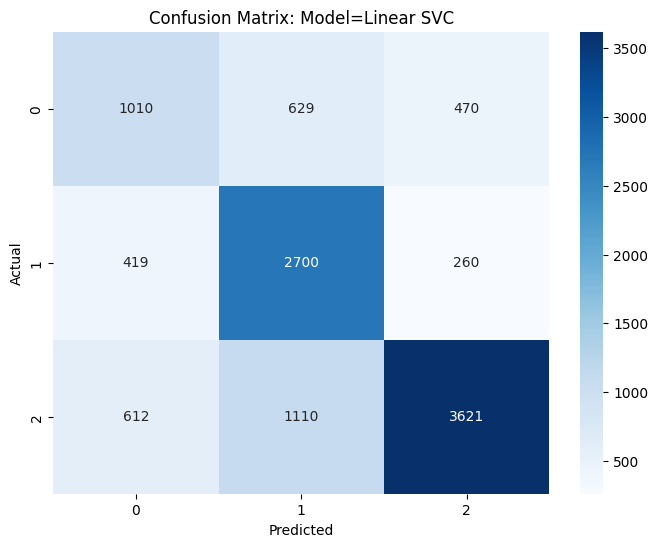


Logistic Regression
0.6732527005816638
              precision    recall  f1-score   support

           0       0.47      0.51      0.48      2109
           1       0.62      0.77      0.69      3379
           2       0.83      0.68      0.75      5343

    accuracy                           0.67     10831
   macro avg       0.64      0.65      0.64     10831
weighted avg       0.70      0.67      0.68     10831



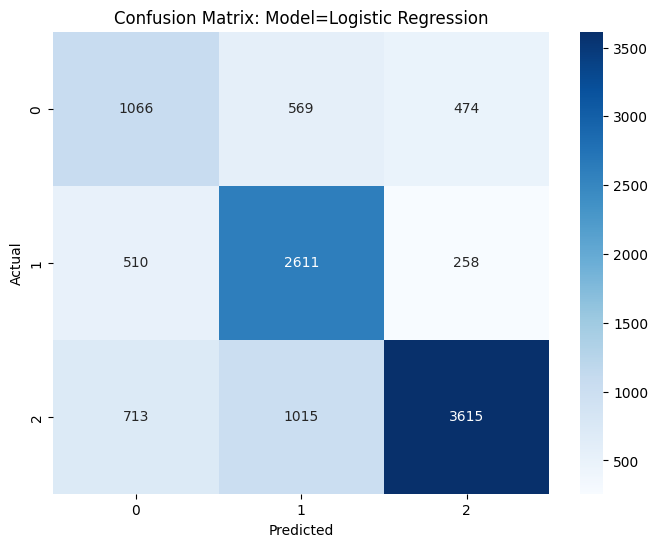


Multinomial NB
0.5123257316960577
              precision    recall  f1-score   support

           0       0.30      0.60      0.40      2109
           1       0.46      0.34      0.39      3379
           2       0.76      0.59      0.66      5343

    accuracy                           0.51     10831
   macro avg       0.51      0.51      0.48     10831
weighted avg       0.58      0.51      0.53     10831



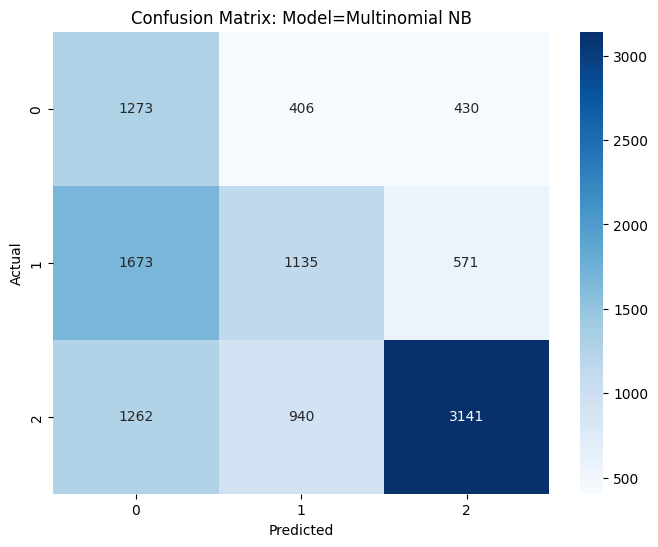


Random Forest
0.6607884775182347
              precision    recall  f1-score   support

           0       0.40      0.42      0.41      2109
           1       0.68      0.64      0.66      3379
           2       0.76      0.77      0.77      5343

    accuracy                           0.66     10831
   macro avg       0.61      0.61      0.61     10831
weighted avg       0.66      0.66      0.66     10831



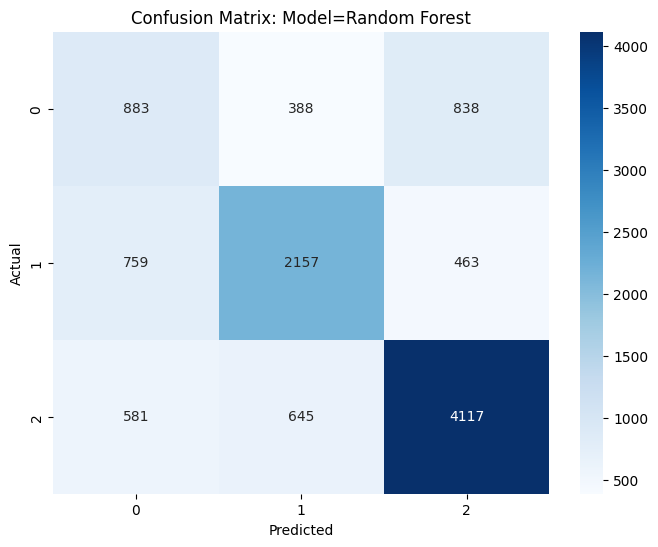


KNN
0.4217523774351399
              precision    recall  f1-score   support

           0       0.26      0.60      0.36      2109
           1       0.49      0.70      0.58      3379
           2       0.86      0.17      0.29      5343

    accuracy                           0.42     10831
   macro avg       0.54      0.49      0.41     10831
weighted avg       0.63      0.42      0.39     10831



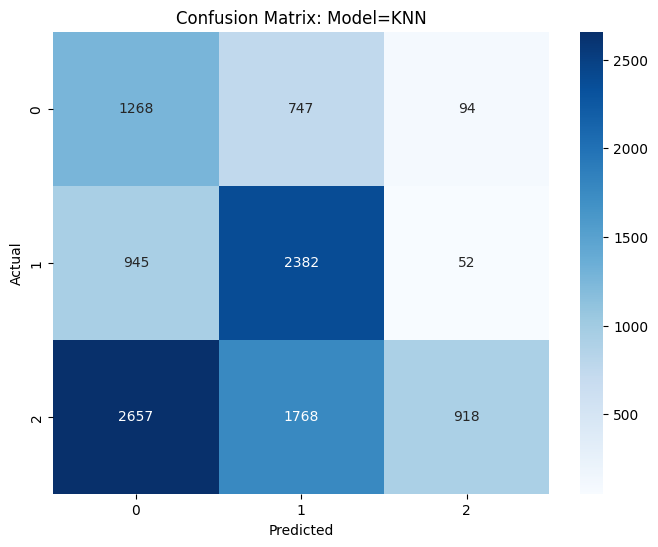


XGBoost
0.7164620072015511
              precision    recall  f1-score   support

           0       0.69      0.37      0.48      2109
           1       0.64      0.85      0.73      3379
           2       0.79      0.77      0.78      5343

    accuracy                           0.72     10831
   macro avg       0.71      0.66      0.66     10831
weighted avg       0.72      0.72      0.71     10831



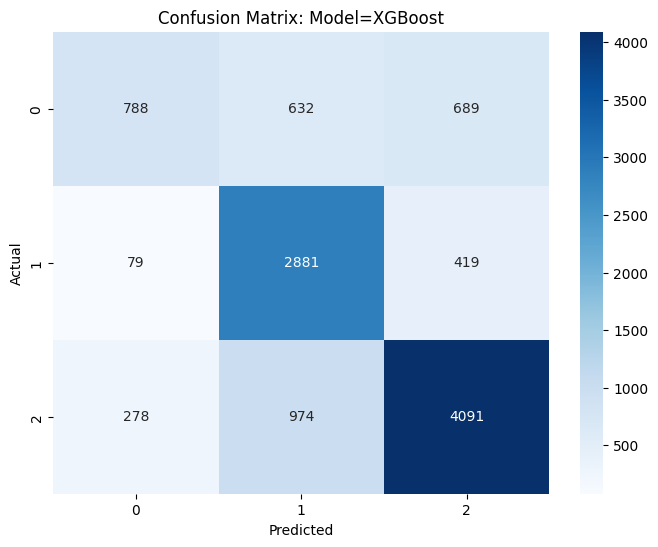


LightGBM


TypeError: Expected np.float32 or np.float64, met type(int64)

In [ ]:
for name, model in models.items():
    print(f"\n{'='*60}")
    print(name)
    print(f"{'='*60}")

    try_models(
        name,
        model,
        X_train_vec,
        X_test_vec,
        y_train,
        y_test
    )

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.694949681469855
              precision    recall  f1-score   support

           0       0.47      0.50      0.48      2109
           1       0.67      0.73      0.70      3379
           2       0.81      0.75      0.78      5343

    accuracy                           0.69     10831
   macro avg       0.65      0.66      0.65     10831
weighted avg       0.70      0.69      0.70     10831



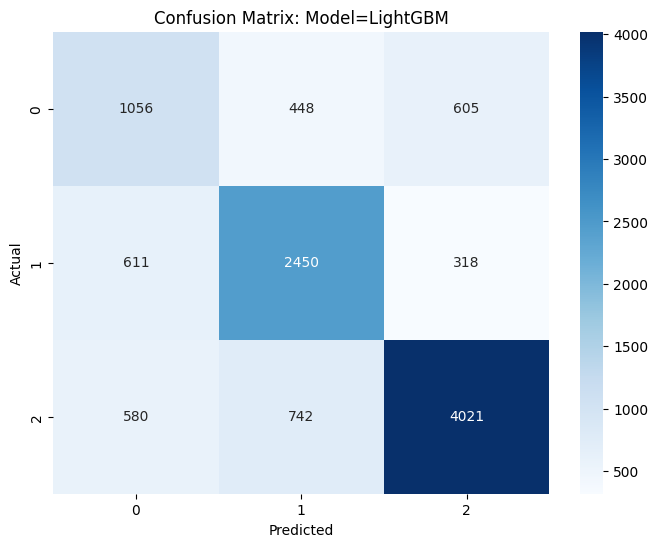

In [ ]:
import numpy as np
try_models("LightGBM", LGBMClassifier(
        random_state=42,
        verbose=-1
    ),  X_train_vec.astype(np.float32),
        X_test_vec.astype(np.float32),
        y_train,
        y_test)

Currently, XG Boost has given the best accuracy and macro average out of all the models.

LightGBM is a close second, its best if i do hyper_parameter tuning of both of them and find out which of them will work best